In [1]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path("~/UNSW-MRes/MRes/seacofs_eddy_dataset_modular").expanduser()

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from seacofs_eddy_dataset.config import load_config

CONFIG_PATH = PROJECT_ROOT / "config" / "local.yaml"
config = load_config(CONFIG_PATH)

# Grid
from seacofs_eddy_dataset.core.grid import read_reference_grid
from seacofs_eddy_dataset.stages.detection import reference_grid_path
grid = read_reference_grid(reference_grid_path(config))


In [2]:
files = sorted((config.output_root / "detections").glob("*.parquet"))

df_nenc = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

df_nenc

,Day,nxc,nyc,Cyc,nic,njc,fnumber
0,1462,830.0,1515.0,AE,245,307,1461
1,1462,358.0,1408.0,AE,136,285,1461
2,1462,928.0,1356.0,CE,261,274,1461
3,1462,506.0,1354.0,CE,179,274,1461
4,1462,754.0,1285.0,AE,231,260,1461
...,...,...,...,...,...,...,...
414944,10650,349.0,158.0,AE,133,32,10641
414945,10650,973.0,126.0,CE,268,26,10641
414946,10650,805.0,95.0,AE,240,19,10641
414947,10650,157.0,34.0,CE,57,7,10641


In [3]:
# import numpy as np
# z_r = np.load('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/z_r.npy')

In [4]:
files = sorted((config.output_root / "surface_eddies").glob("*.parquet"))

df_doppio = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

df_doppio

,Day,fnumber,nxc,nyc,nCyc,nic,njc,xc,yc,w,q11,q12,q22,Omega0,Omega,Rc,psi0,R
0,1462,1461,830.0,1515.0,AE,245,307,829.879126,1515.297884,0.000016,0.705472,-0.172995,1.459911,0.000007,0.000008,93.406313,-37.010850,63.384028
1,1462,1461,358.0,1408.0,AE,136,285,357.902634,1407.794571,0.000032,1.252542,-0.373183,0.909563,0.000015,0.000014,77.893592,-41.235849,50.068171
2,1462,1461,928.0,1356.0,CE,261,274,928.181752,1356.070550,-0.000011,0.918433,-0.656814,1.558529,-0.000004,-0.000007,108.660559,42.689603,74.597458
3,1462,1461,506.0,1354.0,CE,179,274,505.750855,1353.499933,-0.000032,1.091520,-0.174833,0.944157,-0.000016,-0.000014,103.202167,72.408844,69.457705
4,1462,1461,754.0,1285.0,AE,231,260,753.849693,1284.689807,0.000022,1.300245,-0.375378,0.877456,0.000010,0.000009,91.462547,-38.743359,65.961546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414944,10650,10641,349.0,158.0,AE,133,32,348.663439,158.138527,0.000033,1.386381,0.046491,0.722862,0.000016,0.000013,92.830954,-56.075977,43.099927
414945,10650,10641,973.0,126.0,CE,268,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
414946,10650,10641,805.0,95.0,AE,240,19,804.765913,95.382012,0.000011,1.261992,0.398050,0.917949,0.000005,0.000006,63.420966,-11.382331,45.893895
414947,10650,10641,157.0,34.0,CE,57,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
def day_plot(day, df, grid, out_core_flag=False, nenc_flag=False):

    fnumber = 1461 + ((day - 1462) // 30)*30
    fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_{fnumber:05}.nc'
    with nc.Dataset(fname) as ds:
        ocean_time = ds['ocean_time'][:] / 86400
        t = np.where(ocean_time == day)[0][0]
        ut = ds['u_eastward'][t, -1, :, :].T
        vt = ds['v_northward'][t, -1, :, :].T

    df_day = df.loc[df.Day.eq(day)].copy()
    if 'Eddy' not in df_day.columns:
        df_day['Eddy'] = 0
    if 'Cyc' not in df_day.columns:
        df_day['Cyc'] = df_day['nCyc']

    cs = np.hypot(ut, vt)

    fig, ax = plt.subplots(figsize=(8, 10))
    im = ax.pcolor(grid.X_grid, grid.Y_grid, cs, shading='nearest', vmin=0, vmax=2.5, cmap='Blues_r')
    fig.colorbar(im, ax=ax, label=r'Current speed (ms$^{-1}$)')

    clrs = np.where(df_day.Cyc.eq('CE'), 'c', 'r')
    ax.scatter(df_day.xc, df_day.yc, c=clrs, edgecolors='k', linewidths=0.8, s=20, zorder=10)
    if nenc_flag:
        ax.scatter(df_day.nxc, df_day.nyc, c=clrs, edgecolors='k', linewidths=0.8, s=100, zorder=10, marker='x')

    if 'Q' not in df_day.columns:
        df_day['Q'] = list(
            np.stack([
                np.stack([df_day.q11.values, df_day.q12.values], axis=1),
                np.stack([df_day.q12.values, df_day.q22.values], axis=1)
            ], axis=1)
        )

    for xc, yc, e, Q, Rc, R, cyc in zip(df_day.xc, df_day.yc, df_day.Eddy, df_day.Q, df_day.Rc, df_day.R, df_day.Cyc):

        # ----- Where I plot the eddy's maximum tangenital velocity contour -----
        dx_ell, dy_ell = grid.X_grid - xc, grid.Y_grid - yc
        rho2_ell = Q[0,0]*dx_ell**2 + 2*Q[1,0]*dx_ell*dy_ell + Q[1,1]*dy_ell**2 # rho^2
        ax.contour(grid.X_grid, grid.Y_grid, rho2_ell, levels=[Rc**2/2], colors='r' if cyc=='AE' else 'c')
        if out_core_flag:
            ax.contour(grid.X_grid, grid.Y_grid, rho2_ell, levels=[(1.75*R)**2], linestyles='--', colors='r' if cyc=='AE' else 'c')
        # -----------------------------------------------------------------------

        ax.annotate(
            str(e), (xc, yc),
            textcoords='offset points', xytext=(3, 3),
            fontsize=12, color='w', weight='bold',
            path_effects=[pe.withStroke(linewidth=2, foreground='k')],
            zorder=11
        )

    c1 = ax.contour(grid.X_grid, grid.Y_grid, grid.lat_rho, levels=[-40, -35, -30, -25], colors='k', linewidths=.5)
    ax.clabel(c1, fmt=lambda v: f"{np.abs(v):.0f}°S", inline=True, colors='k')
    c2 = ax.contour(grid.X_grid, grid.Y_grid, grid.lon_rho, levels=[150, 155, 160], colors='k', linewidths=.5)
    ax.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')
                
    ax.set_title(f'Day {day} | {pd.Timestamp("1990-01-01") + pd.Timedelta(days=day)}')
    ax.set_aspect('equal', adjustable='datalim')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')
    ax.set_xlim(grid.x_grid.min(), grid.x_grid.max())
    ax.set_ylim(grid.y_grid.min(), grid.y_grid.max())
    

/scratch/pbs.8965008.kman.restech.unsw.edu.au/ipykernel_1795985/545451848.py:30: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(df_day.nxc, df_day.nyc, c=clrs, edgecolors='k', linewidths=0.8, s=100, zorder=10, marker='x')
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


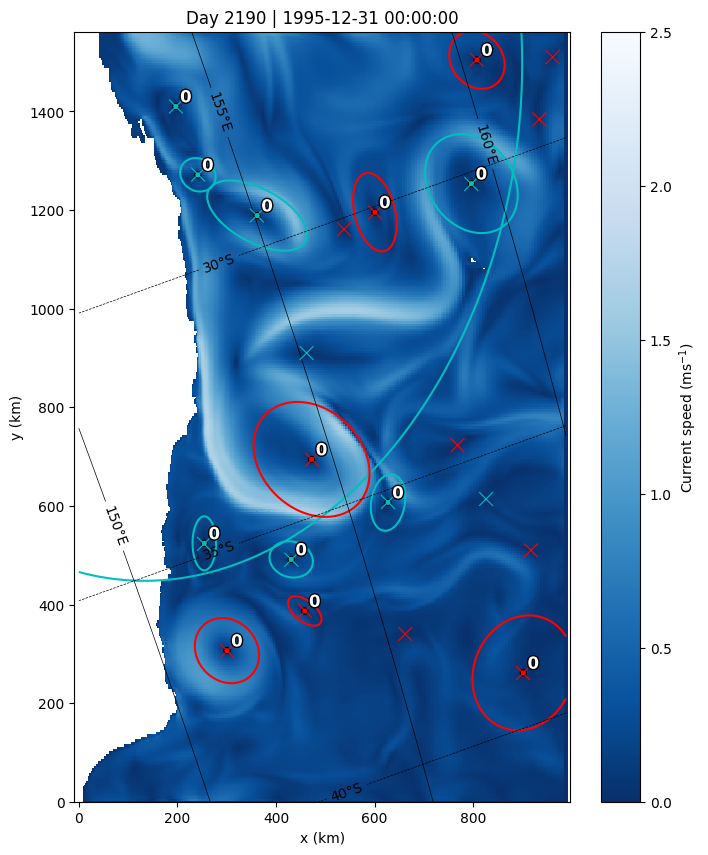

In [6]:
day = 2190
day_plot(day, df_doppio, grid, nenc_flag=True)

In [7]:
df_doppio.dropna()

,Day,fnumber,nxc,nyc,nCyc,nic,njc,xc,yc,w,q11,q12,q22,Omega0,Omega,Rc,psi0,R
0,1462,1461,830.0,1515.0,AE,245,307,829.879126,1515.297884,0.000016,0.705472,-0.172995,1.459911,0.000007,0.000008,93.406313,-37.010850,63.384028
1,1462,1461,358.0,1408.0,AE,136,285,357.902634,1407.794571,0.000032,1.252542,-0.373183,0.909563,0.000015,0.000014,77.893592,-41.235849,50.068171
2,1462,1461,928.0,1356.0,CE,261,274,928.181752,1356.070550,-0.000011,0.918433,-0.656814,1.558529,-0.000004,-0.000007,108.660559,42.689603,74.597458
3,1462,1461,506.0,1354.0,CE,179,274,505.750855,1353.499933,-0.000032,1.091520,-0.174833,0.944157,-0.000016,-0.000014,103.202167,72.408844,69.457705
4,1462,1461,754.0,1285.0,AE,231,260,753.849693,1284.689807,0.000022,1.300245,-0.375378,0.877456,0.000010,0.000009,91.462547,-38.743359,65.961546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414939,10650,10641,852.0,485.0,AE,248,98,851.944525,484.893238,0.000014,0.900701,0.205485,1.157125,0.000007,0.000007,113.525117,-43.542569,68.779464
414941,10650,10641,507.0,302.0,CE,179,61,507.317516,301.765848,-0.000026,1.070874,-0.019005,0.934154,-0.000013,-0.000011,57.115841,17.827252,39.742296
414943,10650,10641,860.0,180.0,CE,250,37,859.994476,179.913208,-0.000008,0.564056,0.178707,1.829491,-0.000003,-0.000003,108.796962,18.457635,62.024070
414944,10650,10641,349.0,158.0,AE,133,32,348.663439,158.138527,0.000033,1.386381,0.046491,0.722862,0.000016,0.000013,92.830954,-56.075977,43.099927


In [8]:
# df_prev_check = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_DOPPIO_SEACOFS_26yr_cleaned_and_50m_vert_checked.pkl')
# df_prev_check


In [9]:
files = sorted((config.output_root / "tracked").glob("*.parquet"))

df_tracked = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

df_tracked

,Day,fnumber,nxc,nyc,nCyc,nic,njc,xc,yc,w,...,Omega,Rc,psi0,R,err,Omega0_abs,Cyc,eddy_idx,Eddy,next_num
0,1462,1461,238.0,40.0,CE,90,8,236.631876,41.645583,-0.000011,...,-0.000005,60.052648,9.238973,38.586312,2.140024,0.000005,CE,0,1,42948
1,1462,1461,534.0,58.0,CE,186,12,536.350493,56.939256,-0.000010,...,-0.000005,45.768796,5.030901,39.213234,2.578759,0.000004,CE,1,2,42948
2,1462,1461,626.0,69.0,AE,206,14,625.197864,69.093112,0.000010,...,0.000005,59.965013,-8.518301,40.158278,0.807522,0.000005,AE,2,3,42948
3,1462,1461,798.0,95.0,CE,239,19,800.076463,95.628623,-0.000015,...,-0.000006,82.665778,20.745926,25.240307,2.169532,0.000006,CE,3,4,42948
4,1462,1461,475.0,131.0,CE,171,27,474.560686,127.605656,-0.000032,...,-0.000014,31.455845,6.679024,20.004291,3.422655,0.000013,CE,4,5,42948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250807,10650,10641,534.0,1136.0,AE,186,230,534.245909,1136.461723,0.000010,...,0.000007,108.470451,-41.238496,62.986679,0.523125,0.000005,AE,12,42925,42948
250808,10650,10641,701.0,1160.0,CE,221,235,701.096481,1160.200240,-0.000021,...,-0.000010,45.911335,10.574898,32.915824,0.222271,0.000010,CE,13,42894,42948
250809,10650,10641,851.0,1214.0,CE,248,246,851.229498,1214.563358,-0.000019,...,-0.000011,81.882356,38.414104,62.049133,0.608311,0.000008,CE,14,42920,42948
250810,10650,10641,320.0,1451.0,AE,122,294,319.928166,1451.113459,0.000033,...,0.000012,114.739891,-77.910685,46.062907,0.134287,0.000015,AE,15,42841,42948


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


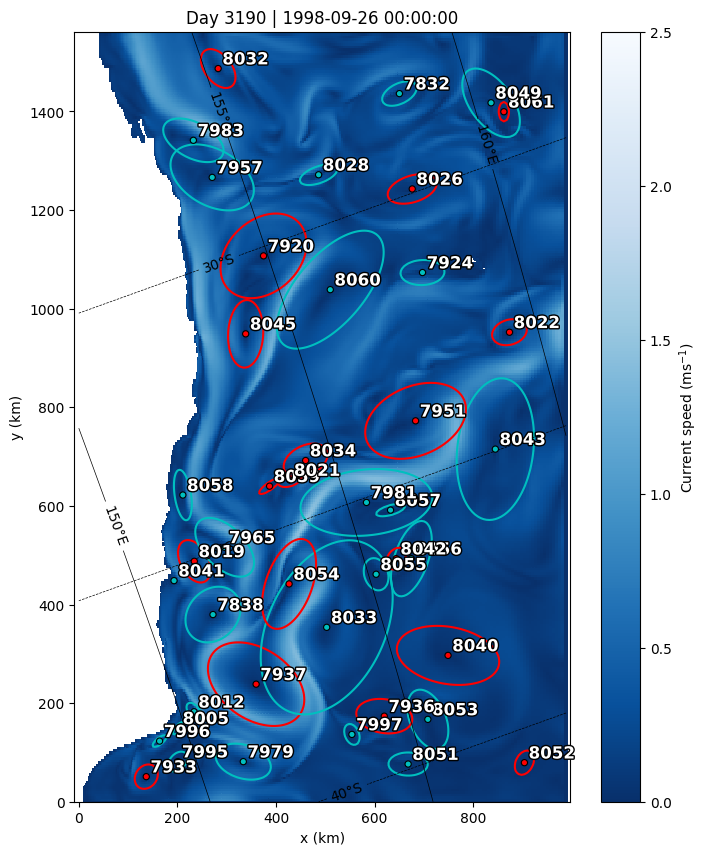

In [10]:
day = 3190
day_plot(day, df_tracked, grid)

In [11]:
df_processed = pd.read_parquet(
    config.output_root / "processed" / "eddy_dataset_processed.parquet"
)

df_processed

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname
0,1,1462,CE,152.716333,-38.866383,171,26,474.560686,127.605656,-0.000034,...,1.758660,-0.532719,0.737370,31.455845,6.679024,1.973172,20.004291,26,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1,1,1463,CE,152.836206,-38.814279,173,28,482.821993,136.635735,-0.000038,...,1.617876,-0.538331,0.816358,32.700506,8.298263,1.859668,18.906549,26,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
2,1,1464,CE,152.905198,-38.816261,175,28,488.606048,138.480541,-0.000038,...,1.393129,-0.557491,0.967292,29.703325,7.116866,1.745185,20.859920,26,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
3,1,1465,CE,152.719389,-38.902070,171,25,475.960098,123.953440,-0.000020,...,1.129925,-0.374295,1.051020,30.687659,7.199754,1.433213,18.674495,26,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
4,1,1466,CE,152.753007,-38.935135,172,25,479.803789,121.483614,-0.000030,...,1.026354,-0.135421,1.060328,31.671992,7.282641,1.140614,21.564028,26,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128599,3023,10646,CE,153.739453,-37.488262,181,61,515.983450,302.961328,-0.000026,...,1.040904,-0.100462,0.978558,71.555984,22.967632,1.110214,55.409919,28,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
128600,3023,10647,CE,153.687115,-37.523299,181,60,512.684226,297.695084,-0.000020,...,1.030802,-0.022352,0.972594,62.338531,19.681675,1.037331,44.896186,28,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
128601,3023,10648,CE,153.699708,-37.537452,181,60,514.199660,296.590511,-0.000022,...,1.056231,-0.010838,0.949624,56.792321,17.808273,1.055789,38.796956,28,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
128602,3023,10649,CE,153.682657,-37.451789,180,62,510.019363,305.068558,-0.000021,...,1.069327,-0.017910,0.937880,57.589129,17.339921,1.070344,40.028670,28,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


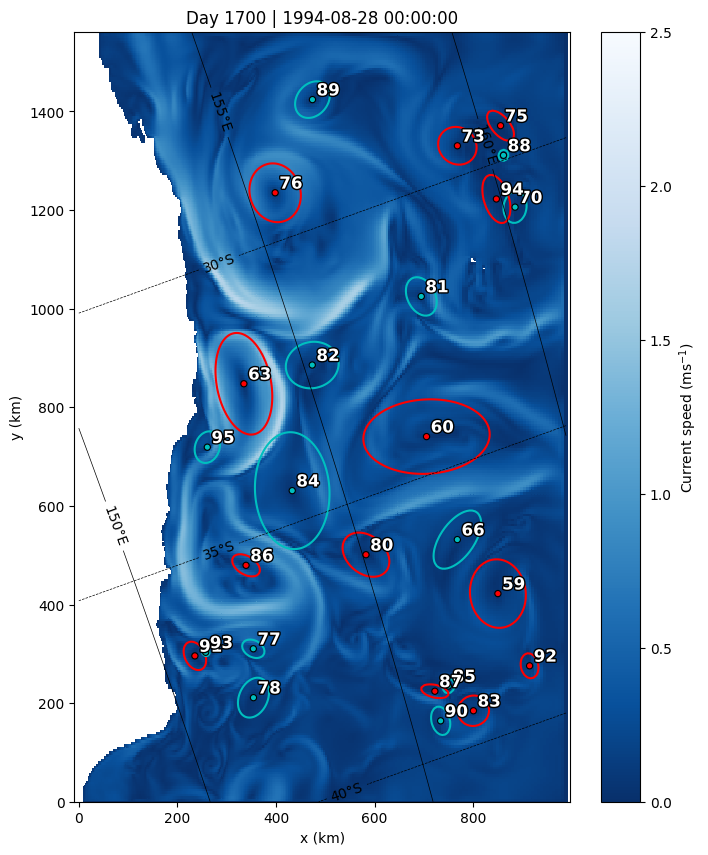

In [31]:
day = 1700
day_plot(day, df_processed, grid)


In [20]:
df_processed.Age.min(), df_processed.Age.max()

(np.int64(22), np.int64(462))

In [28]:
sum(df_processed.Cyc=='AE'), sum(df_processed.Cyc=='CE')

(65483, 63121)

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname
44257,1034,4601,AE,154.625204,-29.973576,131,226,341.884291,1117.115941,0.000013,...,2.197160,0.854801,0.812106,107.040789,-95.278689,2.537586,95.265849,462,2002-08-07,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
44258,1034,4602,AE,154.638892,-30.291028,135,220,354.203600,1084.461857,0.000016,...,2.073275,0.713201,0.757765,107.040789,-95.278689,2.314603,90.615974,462,2002-08-08,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
44259,1034,4603,AE,154.660017,-30.435337,137,217,361.141818,1070.100890,0.000041,...,1.781295,0.500157,0.704288,107.040789,-95.278689,1.973411,64.662633,462,2002-08-09,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
44260,1034,4604,AE,154.683247,-30.496872,139,216,365.388419,1064.441285,0.000015,...,1.664724,0.434206,0.721903,108.793110,-91.578803,1.822202,65.055264,462,2002-08-10,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
44261,1034,4605,AE,154.745612,-30.542783,141,215,372.644838,1061.690838,0.000015,...,1.490182,0.347531,0.768981,110.545431,-87.878918,1.610273,62.800163,462,2002-08-11,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44714,1034,5058,AE,150.074035,-38.715688,95,13,251.457789,65.098713,0.000059,...,1.203451,0.009139,0.836300,57.183778,-47.240543,1.199867,42.205147,462,2003-11-07,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
44715,1034,5059,AE,150.087290,-38.716148,95,13,252.563741,65.441926,0.000059,...,1.145853,-0.011847,0.874445,54.311178,-43.385844,1.145313,42.196961,462,2003-11-08,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
44716,1034,5060,AE,149.981025,-38.782466,93,11,246.143788,55.420844,0.000057,...,1.177663,-0.004472,0.852760,53.540082,-40.153778,1.175234,42.798235,462,2003-11-09,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
44717,1034,5061,AE,149.932726,-38.840772,92,10,244.214852,47.943492,0.000056,...,1.271581,0.085093,0.806660,52.615005,-37.262305,1.274931,41.531862,462,2003-11-10,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


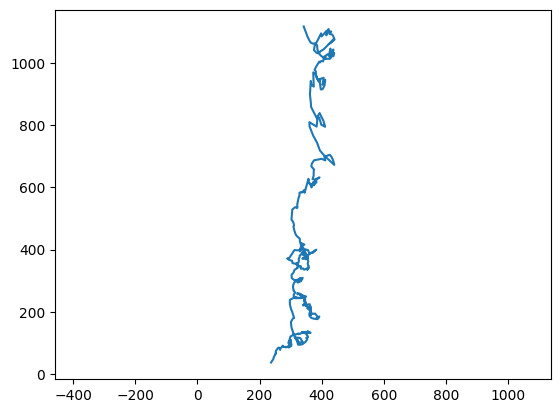

In [27]:
eddy = 1034
df = df_processed[df_processed.Eddy==eddy].copy()
plt.plot(df.xc, df.yc)
plt.axis('equal')
df

(array([15382., 16703., 16099., 13715., 11677.,  8911., 10576., 11164.,
        12335., 12042.]),
 array([  30.02817815,  180.18953956,  330.35090097,  480.51226239,
         630.6736238 ,  780.83498521,  930.99634662, 1081.15770803,
        1231.31906945, 1381.48043086, 1531.64179227]),
 <BarContainer object of 10 artists>)

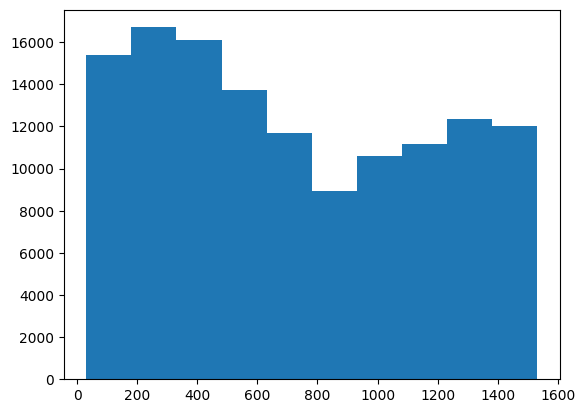

In [14]:
plt.hist(df_processed.yc)